In [3]:
import pandas as pd

df = pd.read_csv('data/airbnb.csv')
df.head()



,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,6499,14455,Entire home/apt,Belém,8,5.0,2,1.0,57.0
1,17031,66015,Entire home/apt,Alvalade,0,0.0,2,1.0,46.0
2,25659,107347,Entire home/apt,Santa Maria Maior,63,5.0,3,1.0,69.0
3,29248,125768,Entire home/apt,Santa Maria Maior,225,4.5,4,1.0,58.0
4,29396,126415,Entire home/apt,Santa Maria Maior,132,5.0,4,1.0,67.0


In [ ]:

import pandas as pd

df_airbnb = pd.read_csv('data/airbnb.csv')
df_airbnb.head()

print("Shape:", df_airbnb.shape)

print("Columnas:", df_airbnb.columns.tolist())

df_airbnb.info()

df_airbnb.describe()

print("Valores nulos por columna:")
print(df_airbnb.isnull().sum())

In [ ]:
# CASO 1
alicia = df_airbnb[
    (df_airbnb['accommodates'] >= 4) & 
    (df_airbnb['bedrooms'] >= 2) & 
    (df_airbnb['reviews'] > 10) & 
    (df_airbnb['overall_satisfaction'] > 4)
]

alicia_sorted = alicia.sort_values(
    by=['overall_satisfaction', 'reviews'], 
    ascending=[False, False]
)

print("Opciones para Alicia:")
alicia_sorted.head(3)


Opciones para Alicia:


,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
120,176153,842219,Entire home/apt,Misericórdia,438,5.0,4,2.0,102.0
16,44043,192830,Entire home/apt,Santa Maria Maior,316,5.0,7,3.0,80.0
140,202150,989393,Entire home/apt,Santa Maria Maior,274,5.0,4,2.0,62.0


In [14]:
# CASO 2

roberto_id = 97503
clara_id = 90387

roberto_clara_df = df_airbnb[
    df_airbnb['room_id'].isin([roberto_id, clara_id])
].copy()

print("\n Comparación de propiedades:\n")
print(roberto_clara_df[['room_id', 'host_id', 'neighborhood', 'reviews', 
                         'overall_satisfaction', 'price']])

if len(roberto_clara_df) == 2:
    roberto_reviews = roberto_clara_df[roberto_clara_df['room_id'] == roberto_id]['reviews'].values[0]
    clara_reviews = roberto_clara_df[roberto_clara_df['room_id'] == clara_id]['reviews'].values[0]
    
    print("\n Análisis:")
    print(f"Roberto (ID: {roberto_id}): {roberto_reviews} reseñas")
    print(f"Clara (ID: {clara_id}): {clara_reviews} reseñas")
    
    if roberto_reviews > clara_reviews:
        print(f" Roberto tiene {roberto_reviews - clara_reviews} reseñas más que Clara")
    else:
        print(f" Clara tiene {clara_reviews - roberto_reviews} reseñas más que Roberto")

roberto_clara_df.to_excel('roberto.xlsx', index=False)
print("\n Archivo 'roberto.xlsx' guardado exitosamente")



 Comparación de propiedades:

    room_id  host_id   neighborhood  reviews  overall_satisfaction  price
41    90387   490050  Santo António      204                   5.0   46.0
48    97503   515924  Santo António       39                   4.0   26.0

 Análisis:
Roberto (ID: 97503): 39 reseñas
Clara (ID: 90387): 204 reseñas
 Clara tiene 165 reseñas más que Roberto

 Archivo 'roberto.xlsx' guardado exitosamente


In [27]:
# CASO 3

diana_filtro = df_airbnb[df_airbnb['price'] <= 50].copy()

diana_filtro['room_priority'] = diana_filtro['room_type'].apply(
    lambda x: 0 if x == 'Shared room' else 1
)

diana_opciones = diana_filtro.sort_values(
    by=['room_priority', 'price', 'overall_satisfaction'],
    ascending=[True, True, False]
).head(10)

print(f"\n Se encontraron {len(diana_filtro)} propiedades con precio ≤ 50")
print("\n TOP 10 OPCIONES RECOMENDADAS PARA DIANA:\n")
print(diana_opciones[['room_id', 'room_type', 'neighborhood', 'price',
                      'overall_satisfaction', 'reviews']])



 Se encontraron 4139 propiedades con precio ≤ 50

 TOP 10 OPCIONES RECOMENDADAS PARA DIANA:

        room_id    room_type       neighborhood  price  overall_satisfaction  \
1010    1179457  Shared room      Santo António   10.0                   4.0   
3562    5557699  Shared room  Santa Maria Maior   10.0                   4.0   
7584   13116032  Shared room            Arroios   10.0                   0.0   
13148  19314160  Shared room        Santa Clara   10.0                   0.0   
9065   14933182  Shared room      Santo António   11.0                   5.0   
4353    6728244  Shared room  Santa Maria Maior   11.0                   4.5   
5616    9317561  Shared room            Arroios   11.0                   4.5   
6640   11693356  Shared room  Santa Maria Maior   11.0                   4.5   
6641   11693442  Shared room  Santa Maria Maior   11.0                   4.5   
8908   14708916  Shared room      Santo António   11.0                   4.5   

       reviews  
1010    

Precio promedio por tipo de habitación:
         room_type       price
0  Entire home/apt  101.338181
1     Private room   45.629967
2      Shared room   34.397661


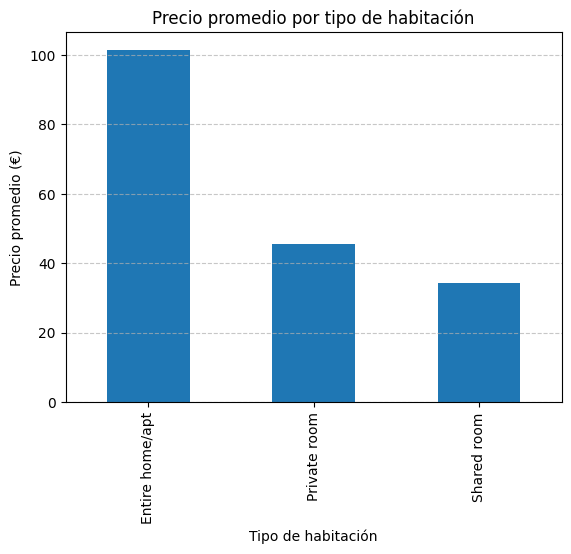


 Top 10 barrios con mayor satisfacción promedio:
         neighborhood  overall_satisfaction
20  Santa Maria Maior              3.732392
0               Ajuda              3.722222
15       Misericórdia              3.695035
23        São Vicente              3.561479
12            Estrela              3.422167
21      Santo António              3.347373
6               Beato              3.297619
7               Belém              3.061024
4             Arroios              3.057797
9    Campo de Ourique              2.996865


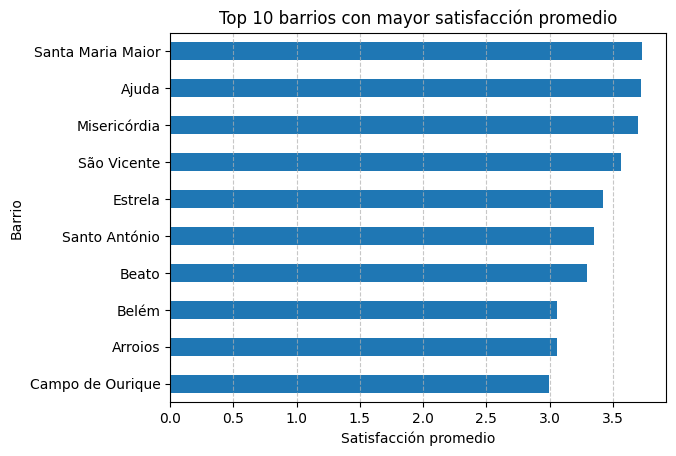

In [7]:
# 3. AGRUPAMIENTOS DE DATOS

import pandas as pd
import matplotlib.pyplot as plt

df_airbnb = pd.read_csv('data/airbnb.csv')

# Agrupamiento 1: Precio promedio por tipo de habitación
group1 = df_airbnb.groupby('room_type')['price'].mean().reset_index()
print("Precio promedio por tipo de habitación:")
print(group1)

# Gráfico del agrupamiento 1 
group1.plot(kind='bar', x='room_type', y='price', legend=False)
plt.title('Precio promedio por tipo de habitación')
plt.xlabel('Tipo de habitación')
plt.ylabel('Precio promedio (€)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Agrupamiento 2: Promedio de satisfacción por barrio
group2 = df_airbnb.groupby('neighborhood')['overall_satisfaction'].mean().reset_index()

top10_barrios = group2.sort_values(by='overall_satisfaction', ascending=False).head(10)

print("\n Top 10 barrios con mayor satisfacción promedio:")
print(top10_barrios)

# Gráfico del agrupamiento 2
top10_barrios.plot(kind='barh', x='neighborhood', y='overall_satisfaction', legend=False)
plt.title('Top 10 barrios con mayor satisfacción promedio')
plt.xlabel('Satisfacción promedio')
plt.ylabel('Barrio')
plt.gca().invert_yaxis()  # Para que el mejor aparezca arriba
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

